# 구글 드라이브의 이미지 불러오기 (catimg.jpg)

대상 파일: `내 드라이브 / catimg / catimg.jpg`

코랩 런타임은 **남의 컴퓨터**입니다. 내 구글 드라이브를 자동으로 알지 못해요.
그래서 먼저 **마운트(mount)** 를 합니다. 외장하드를 USB 포트에 꽂는 것과 같은 일이에요.
꽂고 나면 드라이브가 `/content/drive` 라는 폴더처럼 보이고, 그때부터 평범한 파일처럼 읽을 수 있습니다.


## 1단계 — 드라이브 마운트

아래 셀을 실행하면 **권한 승인 창**이 뜹니다. 구글 계정을 고르고 허용해 주세요.
(VS Code에서 입력창이 안 보이면 명령 팔레트의 `Colab: Mount Google Drive to Server...` 를 쓰세요.)


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


### 1-1단계 — 진단: 지금 코드가 어디서 돌고 있나

문제가 생기면 **추측하지 말고 이 셀부터 실행**하세요.
"지금 이 파이썬이 내 맥북인지 코랩 서버인지"를 먼저 확정해야 합니다.

특히 `EROFS: read-only file system, mkdir '/content'` 같은 에러를 VS Code **모달 창**으로
보셨다면, 그건 코랩 에러가 아닙니다. `/content`는 코랩 서버에만 있는 폴더인데
VS Code가 내 맥북에서 그걸 만들려다 실패한 것입니다. 맥OS는 루트(`/`)가 읽기 전용이에요.

구분법: **모달 창 = 내 맥북 / 셀 아래 빨간 트레이스백 = 코랩 커널**


In [ ]:
import sys, os, platform
from pathlib import Path

print('=== 이 커널은 어디서 도는가 ===')
print('platform      :', sys.platform)            # 코랩이면 linux
print('hostname      :', platform.node())
print('python        :', sys.version.split()[0])
print('현재 작업 폴더 :', os.getcwd())            # 코랩이면 /content

is_colab = 'google.colab' in sys.modules or Path('/content').exists()
print()
print('코랩 런타임인가 :', '예' if is_colab else '아니오 (로컬 파이썬입니다!)')

if not is_colab:
    print()
    print('>> 커널이 코랩이 아닙니다. Select Kernel > Colab > Auto Connect 로 다시 붙이세요.')
else:
    print()
    print('=== 드라이브 마운트 상태 ===')
    dp = Path('/content/drive')
    print('/content/drive 존재 :', dp.exists())
    print('마운트 지점인가     :', os.path.ismount(str(dp)))

    if dp.exists():
        print('/content/drive 내용 :', [p.name for p in dp.iterdir()])

        my = dp / 'MyDrive'
        print()
        print('MyDrive 존재 :', my.exists())
        if my.exists():
            items = sorted(my.iterdir())
            print(f'MyDrive 안 항목 {len(items)}개. 앞 20개:')
            for p in items[:20]:
                print('   ', '[폴더]' if p.is_dir() else '      ', p.name)

            target = my / 'catimg' / 'catimg.jpg'
            print()
            print('catimg 폴더 존재 :', (my / 'catimg').exists())
            print('catimg.jpg 존재  :', target.exists())
            if target.exists():
                print(f'   크기: {target.stat().st_size / 1024:,.1f} KB')
    else:
        print('>> 마운트가 안 됐습니다. 위 1단계 셀을 실행하세요.')


## 2단계 — 경로 찾기 (가장 자주 막히는 지점)

여기서 초보자가 거의 반드시 한 번 걸립니다. 함정이 두 개예요.

**함정 1. `내 드라이브`가 아니라 `MyDrive`입니다.**
웹 화면에는 한글로 `내 드라이브`라고 보이지만, 실제 폴더 이름은 `MyDrive`(띄어쓰기 없음)입니다.
화면에 보이는 이름과 실제 이름이 다른 거예요. 사람에게는 별명으로, 컴퓨터에게는 본명으로 부르는 셈입니다.

**함정 2. 구분자는 `\`가 아니라 `/`입니다.**
윈도우는 `폴더\파일`로 쓰지만 코랩은 리눅스라 `폴더/파일`로 씁니다.

그래서 최종 경로는 이렇게 됩니다.

```
내 드라이브\catimg\catimg.jpg      <- 화면에 보이는 이름
/content/drive/MyDrive/catimg/catimg.jpg   <- 코랩이 아는 실제 경로
```

아래 셀은 경로가 맞는지 먼저 확인하고, 없으면 **비슷한 파일을 찾아서 알려줍니다.**


In [2]:
from pathlib import Path

IMG_PATH = Path('/content/drive/MyDrive/catimg/catimg.jpg')

if IMG_PATH.exists():
    size_kb = IMG_PATH.stat().st_size / 1024
    print(f'찾았습니다: {IMG_PATH}')
    print(f'파일 크기: {size_kb:,.1f} KB')
else:
    print(f'그 경로에 파일이 없습니다: {IMG_PATH}')
    print()

    # 1) 옛 방식(띄어쓰기 있는 My Drive)도 확인
    alt = Path('/content/drive/My Drive/catimg/catimg.jpg')
    if alt.exists():
        print(f'대신 여기 있습니다: {alt}')
        IMG_PATH = alt
    else:
        # 2) 드라이브 전체에서 catimg 라는 이름을 뒤져본다
        root = Path('/content/drive')
        print('드라이브에서 catimg 를 검색합니다...')
        found = list(root.glob('*/catimg*')) + list(root.glob('*/*/catimg*'))
        if found:
            print('비슷한 항목:')
            for f in found[:20]:
                print('  -', f)
        else:
            print('못 찾았습니다. 아래 셀로 폴더 목록을 직접 확인해 보세요.')


찾았습니다: /content/drive/MyDrive/catimg/catimg.jpg
파일 크기: 81.9 KB


경로를 못 찾았다면, 드라이브 안에 뭐가 있는지 눈으로 확인하는 게 빠릅니다.


In [3]:
from pathlib import Path

base = Path('/content/drive/MyDrive')

if base.exists():
    print(f'{base} 안의 항목 (최대 40개):')
    for p in sorted(base.iterdir())[:40]:
        mark = '[폴더]' if p.is_dir() else '      '
        print(' ', mark, p.name)
else:
    print('마운트가 안 된 것 같습니다. 1단계 셀을 다시 실행해 주세요.')


/content/drive/MyDrive 안의 항목 (최대 40개):
  [공개 저장소 보호를 위해 개인 파일 목록 27건을 삭제했습니다]
  [폴더] catimg


## 3단계 — 이미지 열고 정보 확인

`Pillow`(PIL)로 엽니다. 코랩에 기본 설치돼 있어요.

`Image.open()`은 사실 **파일을 통째로 읽지 않습니다.** 헤더만 슬쩍 보고 크기·형식만 파악해 두고,
실제 픽셀은 필요할 때 읽어요(지연 로딩). 그래서 아주 큰 이미지도 `open()` 자체는 순식간입니다.

### 출력의 세 줄을 꼭 확인하세요

**`format`** — **확장자와 다를 수 있습니다.** 파일 이름이 `.jpg`인데 `format`이 `WEBP`로 나오는 일이
흔합니다. 웹에서 저장한 이미지가 대표적이에요. 확장자는 사람이 붙인 **이름표**일 뿐이고,
실제 형식은 파일 **내용**에 적혀 있습니다. PIL은 이름표를 무시하고 내용을 읽으니 여는 데는 문제가
없지만, **나중에 저장할 때 문제가 됩니다** (7단계에서 다룹니다).

**`mode`** — `RGB`면 3채널, **`RGBA`면 투명도(알파)가 붙은 4채널**입니다.
`A`는 Alpha, 즉 "이 픽셀이 얼마나 불투명한가"예요. 0이면 완전 투명, 255면 완전 불투명.
PNG나 WebP로 저장된 이미지에 자주 있습니다. 이것도 7단계에서 발목을 잡습니다.

**`size`** — `(가로, 세로)` 순서입니다. 5단계의 numpy와 순서가 반대라 헷갈리기 쉬워요.


In [4]:
from PIL import Image

img = Image.open(IMG_PATH)

print('형식(format) :', img.format)      # 확장자가 아니라 실제 내용의 형식
print('크기(size)   :', img.size)        # (가로, 세로) 픽셀
print('모드(mode)   :', img.mode)        # RGB=3채널, RGBA=투명도까지 4채널
print()
w, h = img.size
print(f'가로 {w}px x 세로 {h}px = 총 {w * h:,} 픽셀')

# 이후 단계에서 갈림길이 되는 두 가지를 미리 판정해 둔다
HAS_ALPHA = img.mode in ('RGBA', 'LA', 'PA')
print()
print('투명도(알파) 채널 있음 :', HAS_ALPHA)
if HAS_ALPHA:
    print('  -> JPEG로는 그대로 저장할 수 없습니다. 7단계에서 처리합니다.')
if img.format and not str(IMG_PATH).lower().endswith(img.format.lower().replace('jpeg', 'jpg')):
    print(f'  -> 참고: 확장자와 실제 형식({img.format})이 다릅니다. 여는 데는 문제 없습니다.')


형식(format) : WEBP
크기(size)   : (513, 550)
모드(mode)   : RGBA

가로 513px x 세로 550px = 총 282,150 픽셀


## 4단계 — 화면에 띄우기

노트북에서는 변수 이름만 마지막 줄에 두면 그림이 그대로 보입니다.


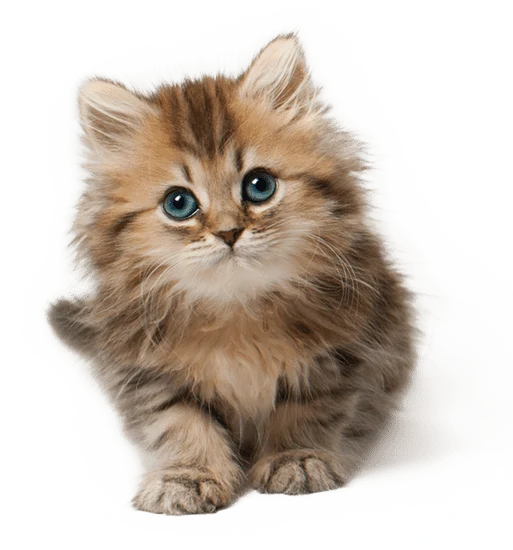

In [5]:
img


### 먼저 한글 폰트를 깔아야 합니다

코랩에는 **한글 폰트가 없습니다.** 그래서 그래프 제목에 한글을 쓰면
글자가 `□□□` 같은 빈 사각형으로 나옵니다. 흔히 **두부 현상**이라고 불러요.

글꼴이 없어서 "이 글자를 어떻게 그려야 할지 모르겠다"는 표시가 네모입니다.
한글 폰트(나눔고딕)를 설치하고 matplotlib에게 "이제 이 폰트를 써라"고 알려주면 해결됩니다.

`!`로 시작하는 줄은 파이썬이 아니라 **리눅스 명령**입니다. 노트북에서 터미널 명령을 쓸 때의 표시예요.
설치는 20~30초쯤 걸리고, 런타임이 새로 붙을 때마다 한 번씩 다시 해야 합니다.


한글 폰트 설정 완료


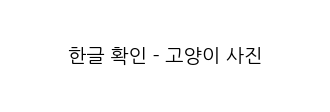

In [6]:
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

try:
    fm.fontManager.addfont(FONT_PATH)
    plt.rcParams['font.family'] = 'NanumGothic'
    print('한글 폰트 설정 완료')
except FileNotFoundError:
    print('나눔고딕을 못 찾았습니다. 그래프 제목은 영어로 나옵니다.')

# 한글 폰트를 쓰면 마이너스 기호가 깨지는 부작용이 있어 따로 끈다
plt.rcParams['axes.unicode_minus'] = False

# 잘 되는지 확인
plt.figure(figsize=(4, 1.2))
plt.text(0.5, 0.5, '한글 확인 - 고양이 사진', ha='center', va='center', fontsize=14)
plt.axis('off')
plt.show()


좀 더 제어하고 싶으면 `matplotlib`을 씁니다. 축을 끄고 제목을 달 수 있어요.


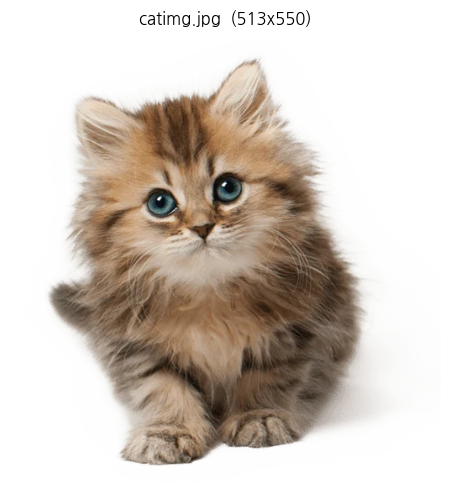

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f'catimg.jpg  ({img.size[0]}x{img.size[1]})')
plt.show()


## 5단계 — 숫자로 바꿔 보기 (이게 핵심)

컴퓨터에게 이미지는 그림이 아니라 **숫자 덩어리**입니다.
모눈종이 한 칸마다 "빨강 얼마, 초록 얼마, 파랑 얼마"라는 세 숫자가 적혀 있는 표예요.
각 숫자는 0(없음)부터 255(최대)까지입니다.

`shape`가 `(높이, 너비, 채널)`로 나오는데, **높이가 먼저** 온다는 점을 조심하세요.
PIL의 `size`는 `(너비, 높이)`인데 numpy는 `(높이, 너비)`라 순서가 반대입니다. 헷갈리기 쉬운 지점입니다.

**마지막 숫자가 4로 나오면** 투명도(알파) 채널이 하나 더 붙은 겁니다.
`(550, 513, 4)` = 세로 550, 가로 513, 채널 4개(R·G·B·A).
알파가 `0`인 픽셀은 완전 투명이라 **화면에 아무것도 안 보이지만 RGB 값은 남아 있습니다.**
그래서 투명한 부분의 RGB를 보면 엉뚱한 색이 찍혀 있을 수 있어요 — 안 보이는 색이니 정상입니다.


In [8]:
import numpy as np

arr = np.array(img)

print('shape :', arr.shape)        # (높이, 너비, 채널)
print('dtype :', arr.dtype)        # uint8 = 0~255 정수
print('최솟값/최댓값 :', arr.min(), '/', arr.max())
print()

n_ch = arr.shape[2] if arr.ndim == 3 else 1
print(f'채널 수: {n_ch}개')
print('맨 왼쪽 위 픽셀 :', arr[0, 0])
print()

names = {3: ['빨강 R', '초록 G', '파랑 B'],
         4: ['빨강 R', '초록 G', '파랑 B', '투명도 A']}.get(n_ch, [f'채널 {i}' for i in range(n_ch)])

print('채널별 평균값')
for i, name in enumerate(names):
    print(f'  {name}: {arr[:, :, i].mean():6.1f}')

# 알파가 있으면 투명 픽셀이 얼마나 되는지도 본다
if n_ch == 4:
    a = arr[:, :, 3]
    transparent = (a == 0).sum()
    opaque = (a == 255).sum()
    total = a.size
    print()
    print(f'완전 투명 픽셀 : {transparent:,} ({transparent / total:.1%})')
    print(f'완전 불투명    : {opaque:,} ({opaque / total:.1%})')


shape : (550, 513, 4)
dtype : uint8
최솟값/최댓값 : 0 / 255

맨 왼쪽 위 픽셀의 RGB : [ 72 112  75   0]

채널별 평균 밝기
  빨강 R:  158.9
  초록 G:  158.1
  파랑 B:  138.3


## 6단계 — 기본 가공 3가지

불러온 이미지로 실제로 뭘 할 수 있는지 감을 잡는 셀입니다.
리사이즈, 흑백 변환, 가운데 잘라내기를 한 번에 비교해 봅니다.

특히 **리사이즈**는 나중에 딥러닝을 할 때 반드시 하게 됩니다.
모델은 정해진 크기(예: 224x224)만 받기 때문에, 사진을 그 틀에 맞춰 넣어야 해요.


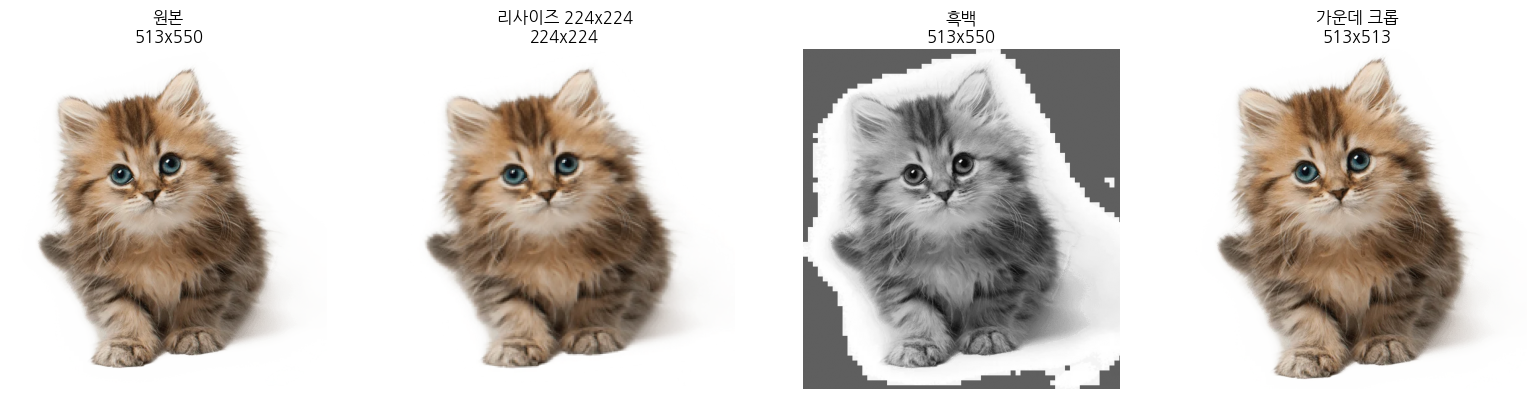

In [9]:
import matplotlib.pyplot as plt

resized = img.resize((224, 224))          # 모델 입력용 표준 크기
gray = img.convert('L')                    # L = 밝기 한 채널만

w, h = img.size
side = min(w, h)
left, top = (w - side) // 2, (h - side) // 2
cropped = img.crop((left, top, left + side, top + side))   # 가운데 정사각형

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, title in zip(
    axes,
    [img, resized, gray, cropped],
    ['원본', f'리사이즈 224x224', '흑백', '가운데 크롭'],
):
    ax.imshow(im, cmap='gray' if im.mode == 'L' else None)
    ax.set_title(f'{title}\n{im.size[0]}x{im.size[1]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 7단계 — 결과 저장하기 (여기서 에러가 납니다)

먼저 나는 에러를 먼저 보시죠.

```
OSError: cannot write mode RGBA as JPEG
```

**원인: JPEG 형식에는 투명도를 담을 칸이 없습니다.**

비유하면, 4칸짜리 짐을 3칸짜리 트렁크에 넣으려는 상황이에요.
이미지는 R·G·B·A 4채널인데 JPEG 트렁크에는 R·G·B 3칸만 있습니다.
PIL은 알파를 조용히 버리는 대신 **"어떻게 할지 네가 정해라"** 하고 멈춰 섭니다.
말없이 데이터를 버리지 않는 건 좋은 설계예요.

확장자가 `.jpg`여서 더 헷갈립니다. 원본은 이름만 `.jpg`이고 실제 내용은 WebP라
알파를 가질 수 있었던 거죠 (3단계의 `format` 출력을 다시 보세요).

### 해결은 두 갈래입니다

| 방법 | 어떻게 | 언제 쓰나 |
|---|---|---|
| **A. PNG로 저장** | 형식을 바꿔 4칸을 확보 | 투명도를 **살려야** 할 때 |
| **B. 배경색 깔고 JPEG** | 투명한 곳을 흰색으로 채워 3칸으로 | JPEG이 **꼭 필요**할 때 (용량 작음) |

**B에서 흔히 하는 실수**: `img.convert('RGB')`만 쓰면 투명했던 부분이 **검정**으로 깔립니다.
실측했습니다 — `convert('RGB')`는 투명 영역을 `[0, 0, 0]`으로, 흰 배경 합성은 `[255, 255, 255]`로
만듭니다. 고양이 사진에서 배경이 새까맣게 나오면 이 때문입니다.
그래서 아래 코드는 **흰 배경을 깔고 그 위에 얹는(paste)** 방식을 씁니다.

그리고 저장 시 주의점 하나. 마운트된 드라이브는 **쓰기도 됩니다.**
원본과 같은 이름으로 저장하면 원본이 사라집니다. 아래 코드는 새 이름을 쓰고,
이미 파일이 있으면 덮어쓰지 않고 건너뜁니다.


In [12]:
from PIL import Image


def save_safely(image, path, bg_color=(255, 255, 255), quality=95):
    """확장자와 이미지 모드를 맞춰서 안전하게 저장한다.

    JPEG은 투명도를 담을 수 없으므로, 알파가 있으면 배경색을 깔고 합성한다.
    PNG/WebP는 투명도를 그대로 지원하므로 손대지 않는다.
    """
    ext = path.suffix.lower()
    has_alpha = image.mode in ('RGBA', 'LA', 'PA', 'P')

    if ext in ('.jpg', '.jpeg') and has_alpha:
        image = image.convert('RGBA')            # P 모드도 일단 RGBA로 통일
        canvas = Image.new('RGB', image.size, bg_color)
        canvas.paste(image, mask=image.split()[-1])   # 알파를 마스크로 써서 얹는다
        image = canvas
        print(f'  알파 채널을 {bg_color} 배경에 합성했습니다')

    if ext in ('.jpg', '.jpeg'):
        image.save(path, quality=quality)
    else:
        image.save(path)
    return path


# --- 방법 A: PNG로 저장 (투명도 유지) ---
print('[A] PNG 저장')
png_path = IMG_PATH.parent / 'catimg_resized.png'
if png_path.exists():
    print(f'  이미 있어 건너뜀: {png_path.name}')
else:
    save_safely(resized, png_path)
    print(f'  저장 완료: {png_path.name}  {png_path.stat().st_size / 1024:,.1f} KB')

# --- 방법 B: 흰 배경 합성 후 JPEG ---
print()
print('[B] JPEG 저장 (흰 배경 합성)')
jpg_path = IMG_PATH.parent / 'catimg_resized.jpg'
if jpg_path.exists():
    print(f'  이미 있어 건너뜀: {jpg_path.name}')
else:
    save_safely(resized, jpg_path)
    print(f'  저장 완료: {jpg_path.name}  {jpg_path.stat().st_size / 1024:,.1f} KB')

# --- 저장된 결과를 다시 열어 확인 ---
print()
print('=== 저장 결과 검증 ===')
for p in [png_path, jpg_path]:
    if p.exists():
        chk = Image.open(p)
        print(f'  {p.name:24s} format={chk.format:5s} mode={chk.mode:5s} size={chk.size}')


[A] PNG 저장
  저장 완료: catimg_resized.png  75.4 KB

[B] JPEG 저장 (흰 배경 합성)
  알파 채널을 (255, 255, 255) 배경에 합성했습니다
  저장 완료: catimg_resized.jpg  14.5 KB

=== 저장 결과 검증 ===
  catimg_resized.png       format=PNG   mode=RGBA  size=(224, 224)
  catimg_resized.jpg       format=JPEG  mode=RGB   size=(224, 224)


### 눈으로 확인: 잘못된 방법 vs 올바른 방법

말로만 들으면 감이 안 오니 직접 비교해 봅니다.
투명한 배경이 검정으로 깔리는지, 흰색으로 깔리는지 보세요.
(원본에 투명 영역이 없으면 세 장이 똑같이 보입니다 — 그것도 정상입니다.)


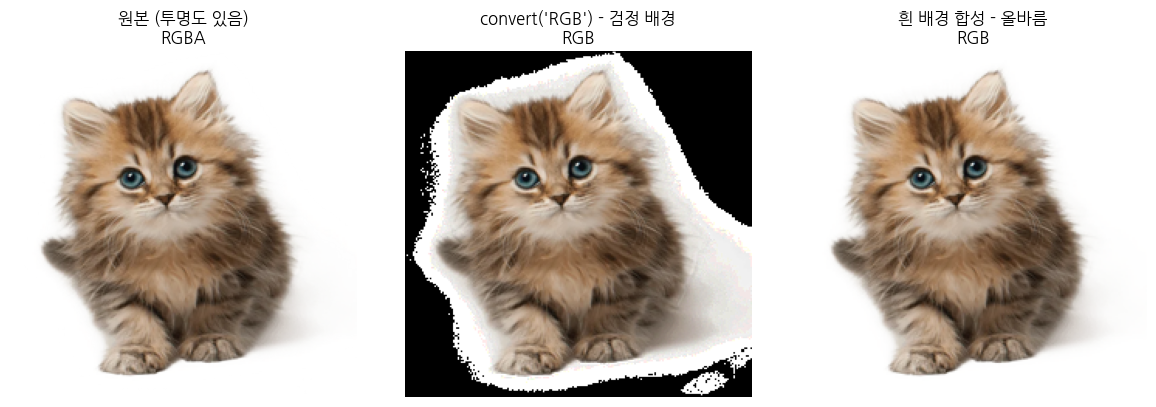

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

wrong = resized.convert('RGB')                       # 투명 -> 검정

right = Image.new('RGB', resized.size, (255, 255, 255))
if resized.mode in ('RGBA', 'LA', 'PA'):
    right.paste(resized, mask=resized.split()[-1])   # 투명 -> 흰색
else:
    right.paste(resized)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(
    axes,
    [resized, wrong, right],
    ['원본 (투명도 있음)', "convert('RGB') - 검정 배경", '흰 배경 합성 - 올바름'],
):
    ax.imshow(im)
    ax.set_title(f'{title}\n{im.mode}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 다음에 할 수 있는 것

이미지를 불러왔으니 여기서 갈 길이 여러 갈래입니다. 이 워크스페이스에 이미 관련 실습이 있어요.

| 하고 싶은 것 | 관련 폴더 |
|---|---|
| 고양이인지 개인지 분류 | `ResNet18_test/` (전이학습 실습) |
| 사진 속 물체 찾아 박스 그리기 | `Yolo_test/` |
| 사진 속 글자 읽기 | `PaddleOCR_test/` |

어느 쪽을 해볼지 말씀해 주시면 이어서 만들어 드립니다.
